# 6. Rheology and Io

A body's tidal response depends on how its material deforms under a periodic load, which is set by its rheology. A rheology combines an elastic shear modulus and a viscosity into a frequency-dependent complex shear modulus. The radial solver turns that into a complex Love number $k_2$. The imaginary part sets the dissipation, so the tidal heating is $-\mathrm{Im}(k_2)$ times orbital factors.

Dissipation peaks at an intermediate viscosity. For a body whose shear modulus is well above its gravitational stiffness $\rho g R$ (about $10^{10}$ Pa for Io), the heating of a Maxwell body peaks near $\eta \approx 2 \rho g R / (19\,\omega)$, about $3 \times 10^{13}$ Pa s for Io, whatever the shear modulus. Only in a much softer body does the peak sit where the Maxwell time (viscosity over shear modulus) matches the tidal period. This notebook maps Io's tidal heating across shear modulus and viscosity for four rheologies, swapping rheologies without rebuilding the planet.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, M_jup
from TidalPy.RadialSolver import homogeneous_love_numbers
from TidalPy.Rheology import Maxwell, Burgers, Andrade, Sundberg

# Io as a homogeneous sphere, tidally forced by Jupiter.
R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
A_IO = 4.217e8
E_IO = 0.0041
N_MOTION = np.sqrt(G * M_jup / A_IO**3)

# Only the complex shear modulus changes between rheologies.
# `homogeneous_love_numbers` builds the homogeneous grid and runs the solver.
SLICES = 60

def love_k2(shear, viscosity, rheology):
    "Complex tidal k2 for a homogeneous Io with the given shear modulus, viscosity, and rheology."
    complex_shear = rheology.calc_complex_modulus(shear, viscosity, N_MOTION)
    solution = homogeneous_love_numbers(R, RHO, complex_shear, N_MOTION, num_slices=SLICES)
    return complex(np.atleast_1d(solution.k)[0])

def heating(shear, viscosity, rheology, ecc=E_IO):
    "Tidal heating [W] from the leading e^2 term: (21/2) (-Im k2) G M_host^2 R^5 e^2 n / a^6."
    neg_im_k2 = -love_k2(shear, viscosity, rheology).imag
    return 10.5 * neg_im_k2 * G * M_jup**2 * R**5 * ecc**2 * N_MOTION / A_IO**6

# Swap rheologies by passing a different object. The planet is not rebuilt.
for name, rheo in [("Maxwell", Maxwell()), ("Andrade", Andrade(0.3, 1.0))]:
    print(f"{name:8}  k2 = {love_k2(60e9, 1e14, rheo):.4f}   heating = {heating(60e9, 1e14, rheo):.3e} W")

Maxwell   k2 = 0.1437-0.3932j   heating = 2.446e+15 W
Andrade   k2 = 0.1955-0.3880j   heating = 2.414e+15 W


## Heating Across Shear Modulus and Viscosity

Each panel maps the tidal heating across mantle shear modulus and viscosity for one rheology. Above a shear modulus of about $10^{10}$ Pa the ridge of strongest heating runs at a nearly constant viscosity of $10^{13}$ to $10^{14}$ Pa s. The transient terms in the Andrade, Burgers, and Sundberg-Cooper rheologies broaden that ridge toward higher viscosity, so they dissipate over a wider range of conditions than a Maxwell body.

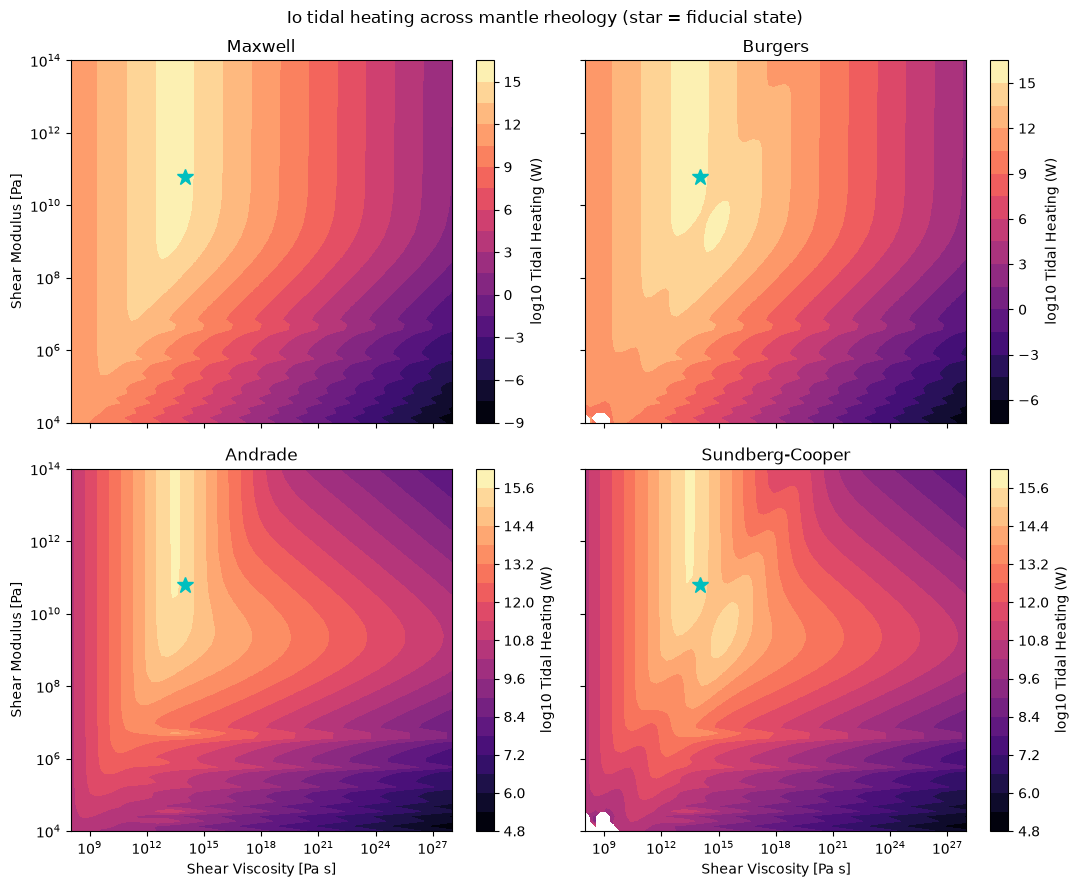

In [2]:
shear_axis = np.logspace(4, 14, 75)
visc_axis = np.logspace(8, 28, 76)
SH, VI = np.meshgrid(shear_axis, visc_axis)

rheologies = [
    ("Maxwell", Maxwell()),
    ("Burgers", Burgers(0.3, 0.05)),
    ("Andrade", Andrade(0.3, 1.0)),
    ("Sundberg-Cooper", Sundberg(0.3, 1.0, 0.2, 0.02)),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, rheo) in zip(axes.ravel(), rheologies):
    grid = np.array([[heating(mu, eta, rheo) for mu in shear_axis] for eta in visc_axis])
    # In the nearly fluid corner (low modulus and viscosity) the dissipation is below the solver's resolution.
    # The few cells that come out zero or slightly negative are left blank.
    log_grid = np.log10(np.where(grid > 0.0, grid, np.nan))
    cf = ax.contourf(VI, SH, log_grid, levels=20, cmap="magma")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(name)
    ax.plot(1.0e14, 60e9, "c*", ms=12)      # a fiducial mantle state
    fig.colorbar(cf, ax=ax, label="log10 Tidal Heating (W)")
for ax in axes[-1]:
    ax.set_xlabel("Shear Viscosity [Pa s]")
for ax in axes[:, 0]:
    ax.set_ylabel("Shear Modulus [Pa]")
fig.suptitle("Io tidal heating across mantle rheology (star = fiducial state)")
fig.tight_layout()
plt.show()


## Heating Versus Eccentricity Across Rheologies

At a fixed mantle state, all four rheologies scale as $e^2$ but differ in absolute level, since each converts the same forcing into a different amount of dissipation. The eccentricity range covers the values Io is thought to have had (Hussmann & Spohn 2004).

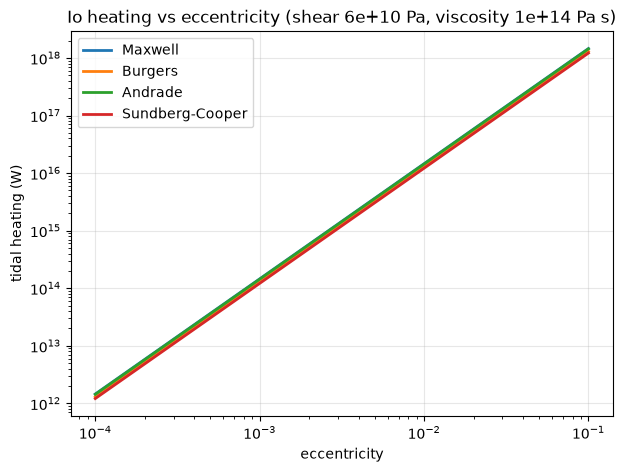

In [3]:
eccs = np.logspace(-4, -1, 60)
mu0, eta0 = 60.0e9, 1.0e14

fig, ax = plt.subplots(figsize=(7, 5))
for name, rheo in rheologies:
    curve = [heating(mu0, eta0, rheo, ecc=e) for e in eccs]
    ax.loglog(eccs, curve, lw=2, label=name)
ax.set_xlabel("eccentricity")
ax.set_ylabel("tidal heating (W)")
ax.set_title(f"Io heating vs eccentricity (shear {mu0:.0e} Pa, viscosity {eta0:.0e} Pa s)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
